<a href="https://www.kaggle.com/code/lalit7881/college-major-roi-eda-99-81?scriptVersionId=352303249" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sergionefedov/college-major-roi/college_major_roi.csv
/kaggle/input/datasets/sergionefedov/college-major-roi/data_dictionary (6).csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/sergionefedov/college-major-roi/college_major_roi.csv")

In [3]:
df.head()

,grad_id,major,major_category,institution_tier,institution_selectivity_pctile,gpa,had_internship,completed_on_time,region,net_cost_usd,debt_usd,hs_baseline_10yr_usd,added_earnings_10yr_usd,earnings_10yr_usd,net_roi_usd,roi_pct,positive_roi,high_roi
0,G000000,biology,STEM,mid_tier,52,2.58,0,0,south,144400,0,411700,101000,512700,-43400,-30.0,0,0
1,G000001,marketing,business,mid_tier,61,2.58,0,1,northeast,57400,0,356900,330600,687500,273200,476.1,1,0
2,G000002,electrical_engineering,STEM,top_public,78,3.14,1,1,northeast,65100,39600,339600,655100,994700,590000,906.4,1,1
3,G000003,marketing,business,top_public,77,3.04,0,1,midwest,105800,81300,399600,197500,597100,91700,86.8,1,0
4,G000004,marketing,business,ivy_elite,100,3.81,0,0,south,219200,93500,335700,222900,558600,3800,1.7,1,0


In [4]:
df.tail()

,grad_id,major,major_category,institution_tier,institution_selectivity_pctile,gpa,had_internship,completed_on_time,region,net_cost_usd,debt_usd,hs_baseline_10yr_usd,added_earnings_10yr_usd,earnings_10yr_usd,net_roi_usd,roi_pct,positive_roi,high_roi
29995,G029995,electrical_engineering,STEM,top_public,71,3.47,1,1,south,71900,0,338500,521600,860100,449700,625.4,1,1
29996,G029996,humanities,humanities,regional,46,3.62,0,1,south,61300,41300,378100,55400,433500,-5900,-9.6,0,0
29997,G029997,economics,business,for_profit,26,3.34,0,1,west,154000,0,432900,406500,839400,252500,163.9,1,0
29998,G029998,social_work,social_science,mid_tier,58,2.95,0,0,northeast,124100,50300,423300,53500,476800,-70500,-56.9,0,0
29999,G029999,chemical_engineering,STEM,regional,38,2.35,1,1,midwest,53900,51800,381800,602100,983800,548200,1016.9,1,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   grad_id                         30000 non-null  object 
 1   major                           30000 non-null  object 
 2   major_category                  30000 non-null  object 
 3   institution_tier                30000 non-null  object 
 4   institution_selectivity_pctile  30000 non-null  int64  
 5   gpa                             30000 non-null  float64
 6   had_internship                  30000 non-null  int64  
 7   completed_on_time               30000 non-null  int64  
 8   region                          30000 non-null  object 
 9   net_cost_usd                    30000 non-null  int64  
 10  debt_usd                        30000 non-null  int64  
 11  hs_baseline_10yr_usd            30000 non-null  int64  
 12  added_earnings_10yr_usd         

In [6]:
df.describe()

,institution_selectivity_pctile,gpa,had_internship,completed_on_time,net_cost_usd,debt_usd,hs_baseline_10yr_usd,added_earnings_10yr_usd,earnings_10yr_usd,net_roi_usd,roi_pct,positive_roi,high_roi
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,3.000000e+04,3.000000e+04,30000.000000,30000.000000,30000.00000
mean,55.086067,3.093337,0.436067,0.682367,88621.496667,38498.063333,359893.416667,3.554752e+05,7.153680e+05,2.668537e+05,346.153987,0.835167,0.25000
std,18.593708,0.439060,0.495904,0.465564,33576.903160,37801.748200,39923.943255,2.948109e+05,2.977847e+05,2.949958e+05,398.666879,0.371036,0.43302
min,16.000000,1.500000,0.000000,0.000000,28500.000000,0.000000,250000.000000,1.000000e+04,2.723000e+05,-3.052000e+05,-92.100000,0.000000,0.00000
25%,42.000000,2.790000,0.000000,0.000000,65500.000000,0.000000,333100.000000,1.179000e+05,4.835000e+05,3.280000e+04,39.700000,1.000000,0.00000
50%,55.000000,3.100000,0.000000,1.000000,81000.000000,38700.000000,359700.000000,2.836500e+05,6.458000e+05,1.981000e+05,230.900000,1.000000,0.00000
75%,68.000000,3.400000,1.000000,1.000000,103600.000000,62300.000000,387300.000000,5.093000e+05,8.717000e+05,4.235250e+05,537.400000,1.000000,0.25000
max,102.000000,4.000000,1.000000,1.000000,352900.000000,331700.000000,480000.000000,2.894900e+06,3.245500e+06,2.755100e+06,3618.900000,1.000000,1.00000


In [7]:
df.isnull().sum()

grad_id                           0
major                             0
major_category                    0
institution_tier                  0
institution_selectivity_pctile    0
gpa                               0
had_internship                    0
completed_on_time                 0
region                            0
net_cost_usd                      0
debt_usd                          0
hs_baseline_10yr_usd              0
added_earnings_10yr_usd           0
earnings_10yr_usd                 0
net_roi_usd                       0
roi_pct                           0
positive_roi                      0
high_roi                          0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

grad_id                            object
major                              object
major_category                     object
institution_tier                   object
institution_selectivity_pctile      int64
gpa                               float64
had_internship                      int64
completed_on_time                   int64
region                             object
net_cost_usd                        int64
debt_usd                            int64
hs_baseline_10yr_usd                int64
added_earnings_10yr_usd             int64
earnings_10yr_usd                   int64
net_roi_usd                         int64
roi_pct                           float64
positive_roi                        int64
high_roi                            int64
dtype: object

In [10]:
df.shape

(30000, 18)

In [11]:
df.columns

Index(['grad_id', 'major', 'major_category', 'institution_tier',
       'institution_selectivity_pctile', 'gpa', 'had_internship',
       'completed_on_time', 'region', 'net_cost_usd', 'debt_usd',
       'hs_baseline_10yr_usd', 'added_earnings_10yr_usd', 'earnings_10yr_usd',
       'net_roi_usd', 'roi_pct', 'positive_roi', 'high_roi'],
      dtype='object')

In [12]:
df.nunique()

grad_id                           30000
major                                19
major_category                        7
institution_tier                      5
institution_selectivity_pctile       65
gpa                                 244
had_internship                        2
completed_on_time                     2
region                                4
net_cost_usd                       1879
debt_usd                           1504
hs_baseline_10yr_usd               2113
added_earnings_10yr_usd            9116
earnings_10yr_usd                  9578
net_roi_usd                        9522
roi_pct                           10848
positive_roi                          2
high_roi                              2
dtype: int64

## EDA

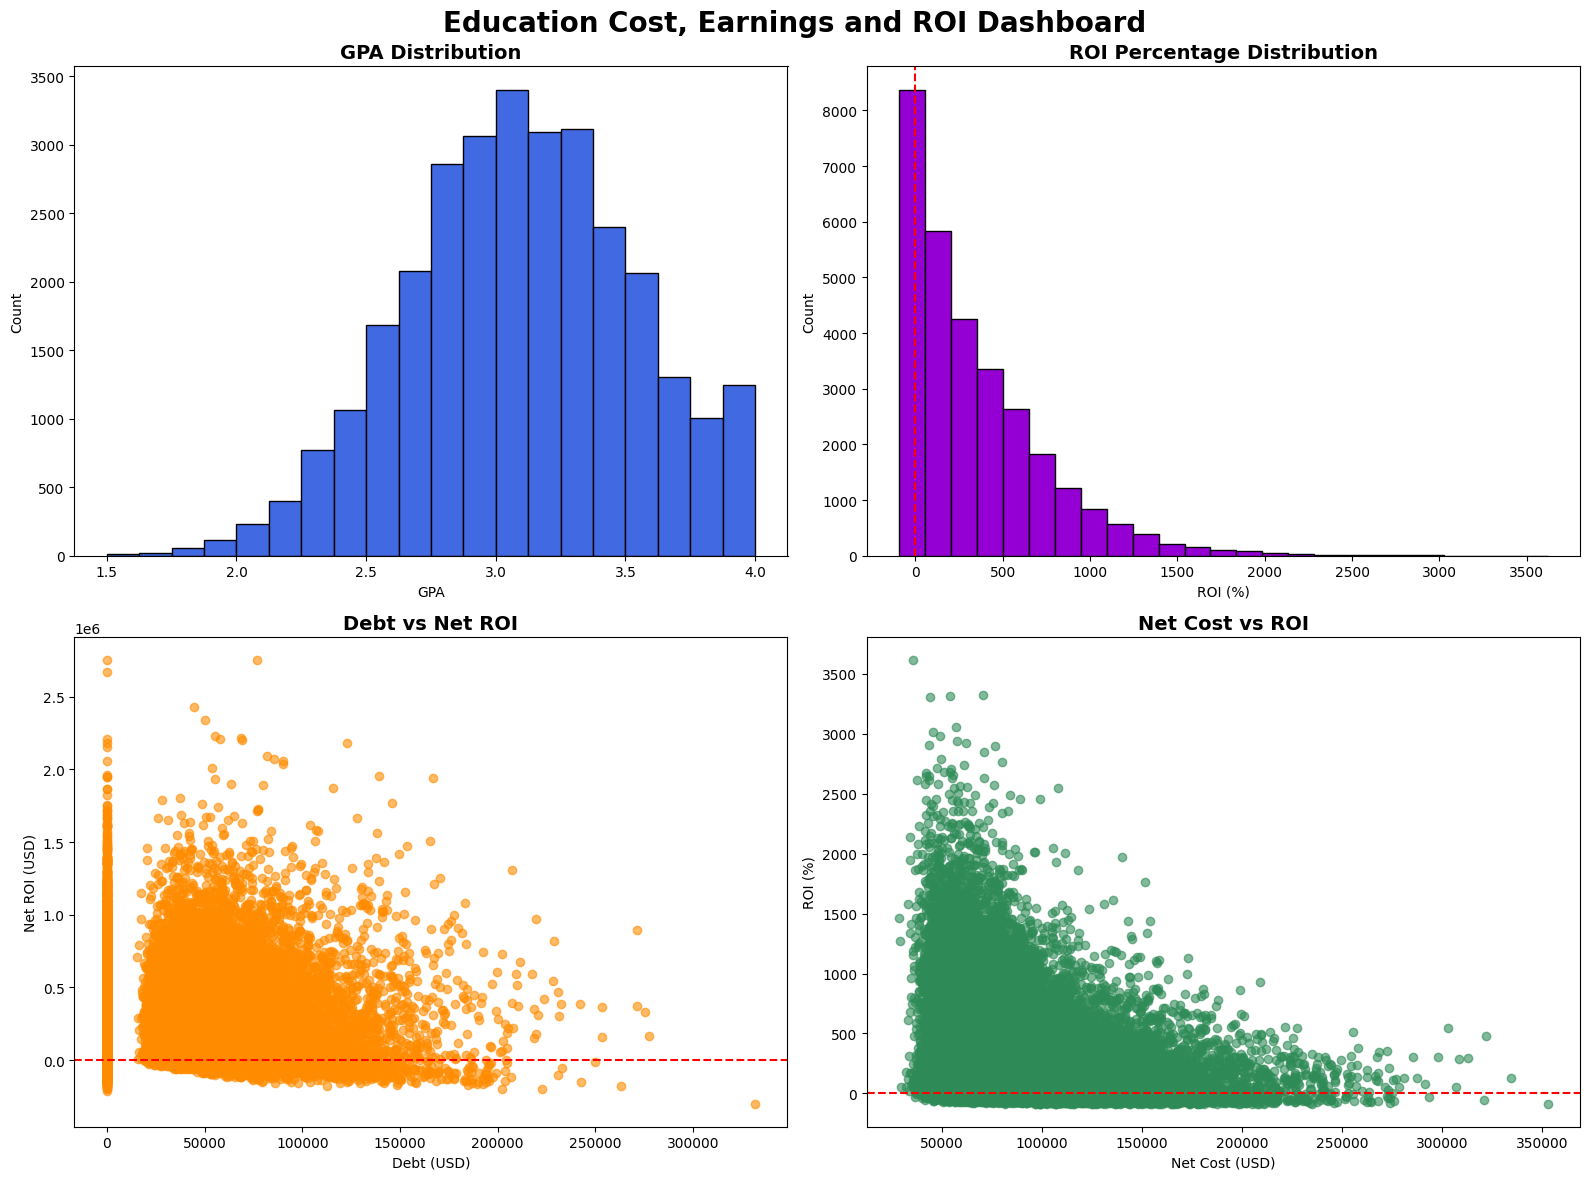

In [13]:
# ============================================
# 34. FINAL KEY VISUALIZATIONS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# -----------------------------
# GPA
# -----------------------------
axes[0, 0].hist(
    df['gpa'].dropna(),
    bins=20,
    color='royalblue',
    edgecolor='black'
)

axes[0, 0].set_title(
    'GPA Distribution',
    fontsize=14,
    fontweight='bold'
)

axes[0, 0].set_xlabel('GPA')
axes[0, 0].set_ylabel('Count')

# -----------------------------
# ROI
# -----------------------------
axes[0, 1].hist(
    df['roi_pct'].dropna(),
    bins=25,
    color='darkviolet',
    edgecolor='black'
)

axes[0, 1].axvline(
    0,
    color='red',
    linestyle='--'
)

axes[0, 1].set_title(
    'ROI Percentage Distribution',
    fontsize=14,
    fontweight='bold'
)

axes[0, 1].set_xlabel('ROI (%)')
axes[0, 1].set_ylabel('Count')

# -----------------------------
# Debt vs ROI
# -----------------------------
axes[1, 0].scatter(
    df['debt_usd'],
    df['net_roi_usd'],
    color='darkorange',
    alpha=0.6
)

axes[1, 0].axhline(
    0,
    color='red',
    linestyle='--'
)

axes[1, 0].set_title(
    'Debt vs Net ROI',
    fontsize=14,
    fontweight='bold'
)

axes[1, 0].set_xlabel('Debt (USD)')
axes[1, 0].set_ylabel('Net ROI (USD)')

# -----------------------------
# Net Cost vs ROI
# -----------------------------
axes[1, 1].scatter(
    df['net_cost_usd'],
    df['roi_pct'],
    color='seagreen',
    alpha=0.6
)

axes[1, 1].axhline(
    0,
    color='red',
    linestyle='--'
)

axes[1, 1].set_title(
    'Net Cost vs ROI',
    fontsize=14,
    fontweight='bold'
)

axes[1, 1].set_xlabel('Net Cost (USD)')
axes[1, 1].set_ylabel('ROI (%)')

plt.suptitle(
    'Education Cost, Earnings and ROI Dashboard',
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## Feature engineering

Dataset Shape: (30000, 18)

Columns:
['grad_id', 'major', 'major_category', 'institution_tier', 'institution_selectivity_pctile', 'gpa', 'had_internship', 'completed_on_time', 'region', 'net_cost_usd', 'debt_usd', 'hs_baseline_10yr_usd', 'added_earnings_10yr_usd', 'earnings_10yr_usd', 'net_roi_usd', 'roi_pct', 'positive_roi', 'high_roi']

First 5 Rows:


,grad_id,major,major_category,institution_tier,institution_selectivity_pctile,gpa,had_internship,completed_on_time,region,net_cost_usd,debt_usd,hs_baseline_10yr_usd,added_earnings_10yr_usd,earnings_10yr_usd,net_roi_usd,roi_pct,positive_roi,high_roi
0,G000000,biology,STEM,mid_tier,52,2.58,0,0,south,144400,0,411700,101000,512700,-43400,-30.0,0,0
1,G000001,marketing,business,mid_tier,61,2.58,0,1,northeast,57400,0,356900,330600,687500,273200,476.1,1,0
2,G000002,electrical_engineering,STEM,top_public,78,3.14,1,1,northeast,65100,39600,339600,655100,994700,590000,906.4,1,1
3,G000003,marketing,business,top_public,77,3.04,0,1,midwest,105800,81300,399600,197500,597100,91700,86.8,1,0
4,G000004,marketing,business,ivy_elite,100,3.81,0,0,south,219200,93500,335700,222900,558600,3800,1.7,1,0



Missing Values:
grad_id                           0
major                             0
major_category                    0
institution_tier                  0
institution_selectivity_pctile    0
gpa                               0
had_internship                    0
completed_on_time                 0
region                            0
net_cost_usd                      0
debt_usd                          0
hs_baseline_10yr_usd              0
added_earnings_10yr_usd           0
earnings_10yr_usd                 0
net_roi_usd                       0
roi_pct                           0
positive_roi                      0
high_roi                          0
dtype: int64

Target Variable: positive_roi

Target Distribution:
positive_roi
1    25055
0     4945
Name: count, dtype: int64

Target Percentage:
positive_roi
1    83.516667
0    16.483333
Name: proportion, dtype: float64

Columns removed:
['grad_id', 'net_roi_usd', 'roi_pct', 'high_roi']

Remaining columns:
['major', 'major_categor

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9968,0.9976,0.9986,0.9981,1.0000
1,Gradient Boosting,0.9935,0.9942,0.9980,0.9961,0.9998
2,Random Forest,0.9898,0.9924,0.9954,0.9939,0.9994
3,Extra Trees,0.9573,0.9612,0.9888,0.9748,0.9928
4,Decision Tree,0.9928,0.9952,0.9962,0.9957,0.9891
5,Naive Bayes,0.8902,0.9939,0.8739,0.9300,0.9645
6,KNN,0.9083,0.9317,0.9607,0.9460,0.9392


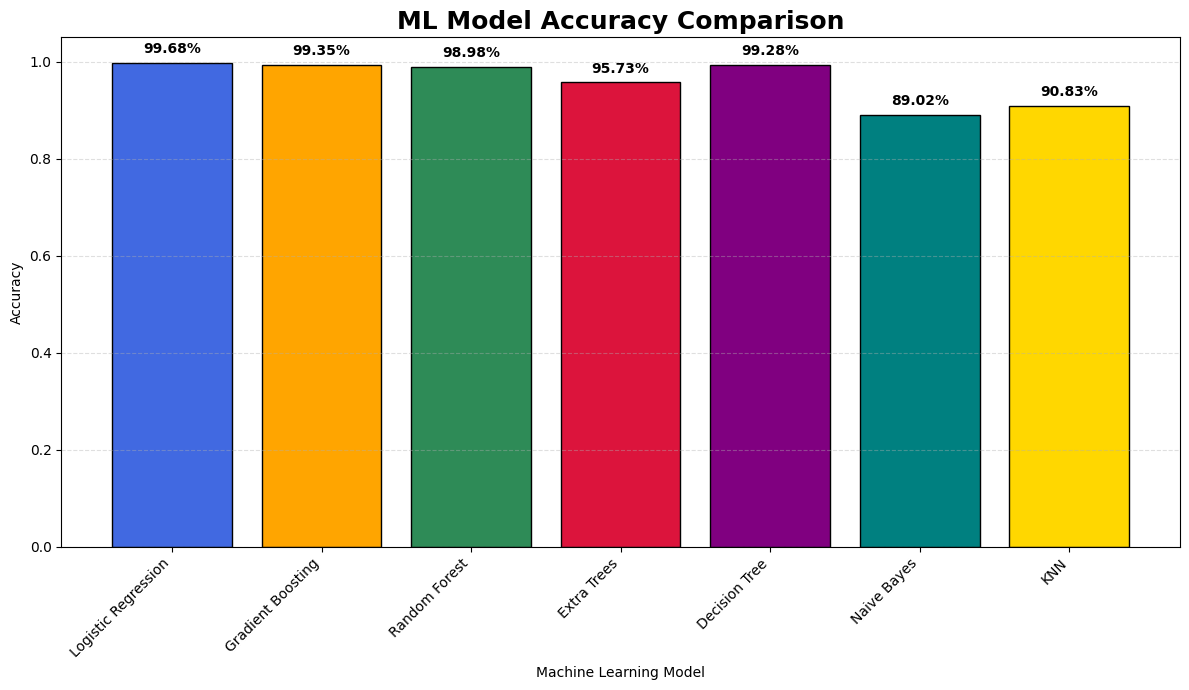

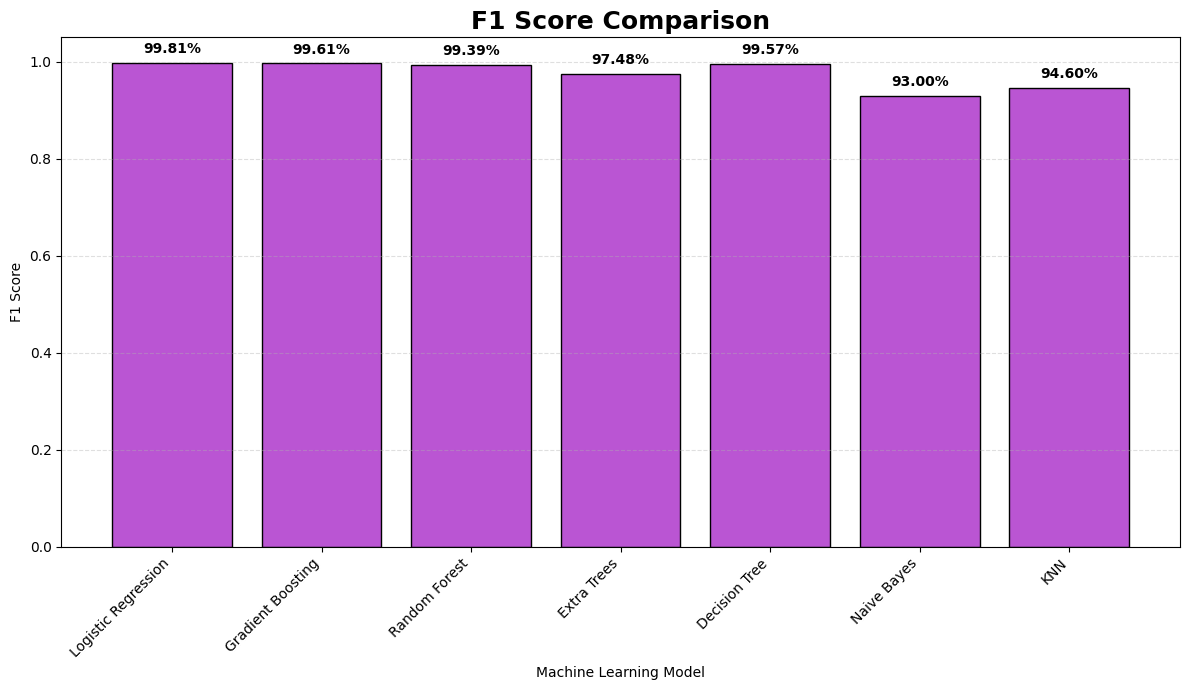

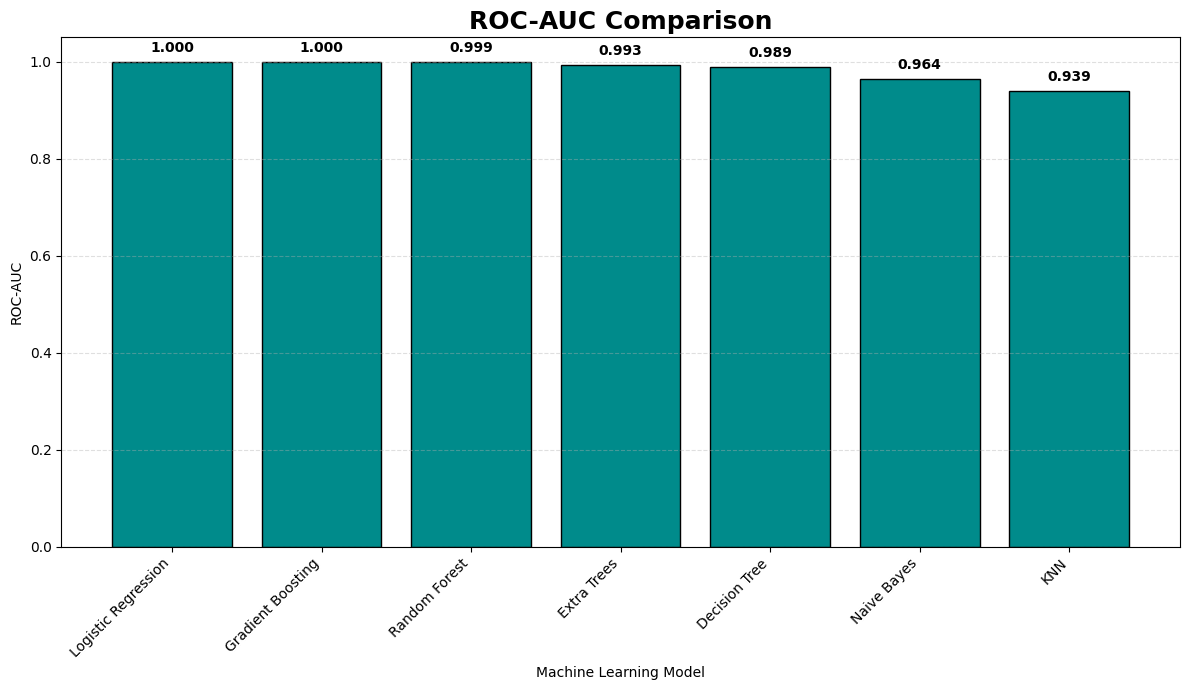

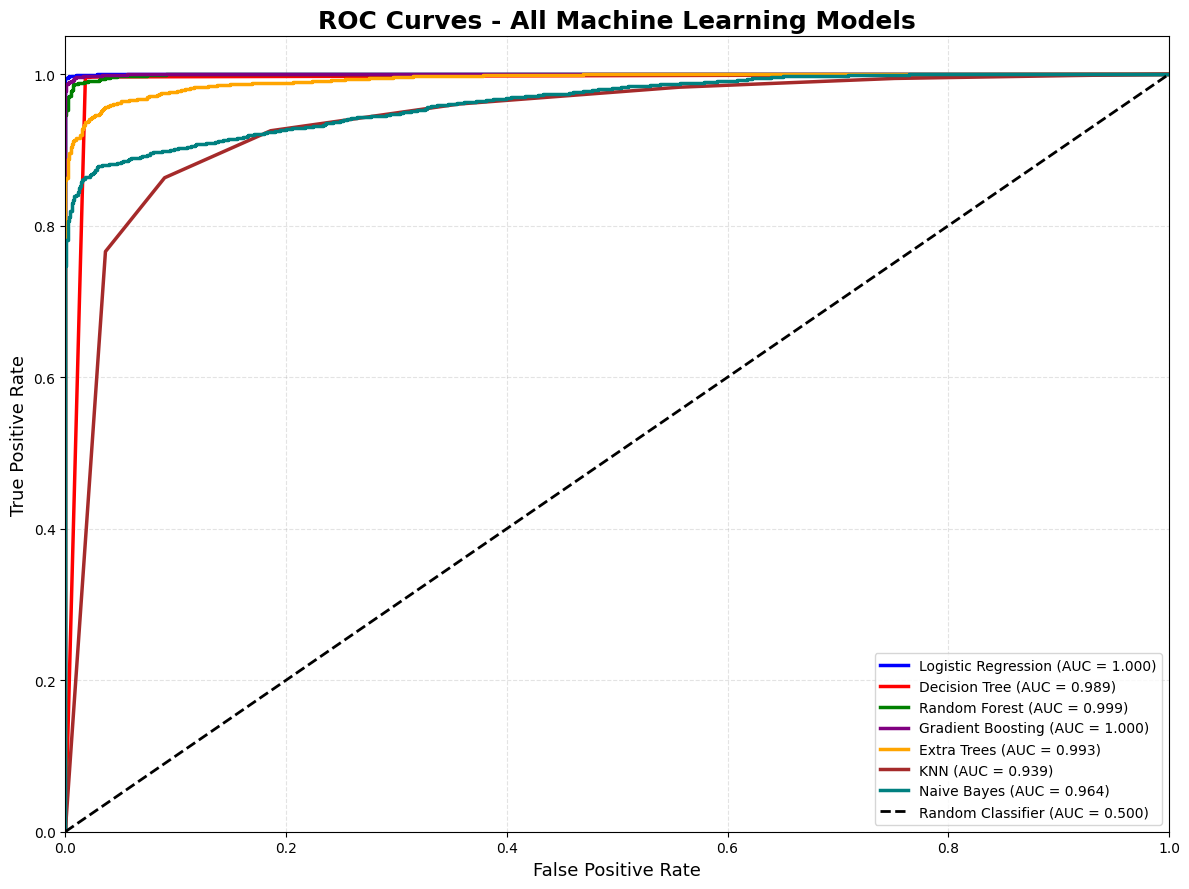

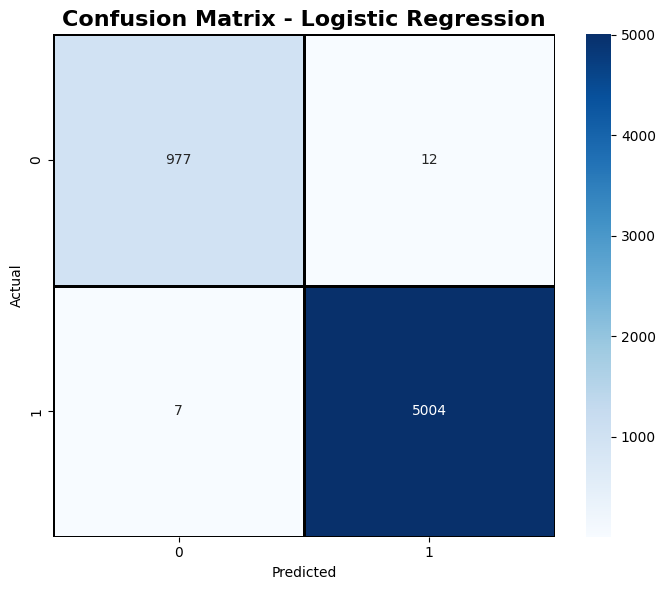

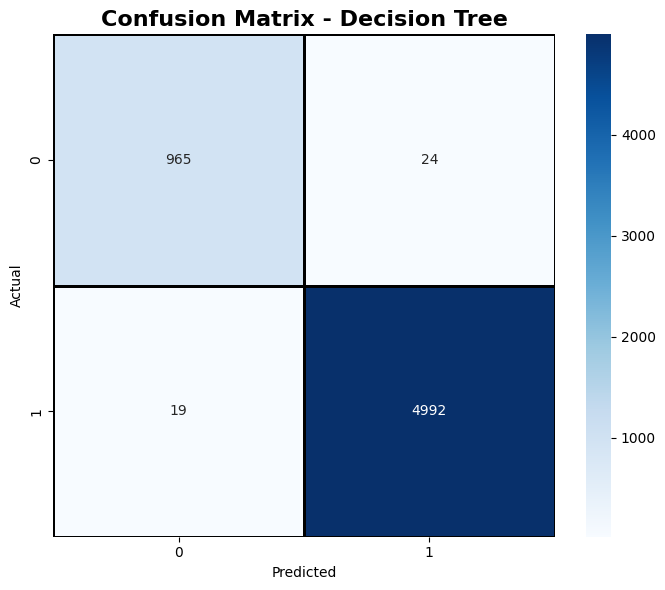

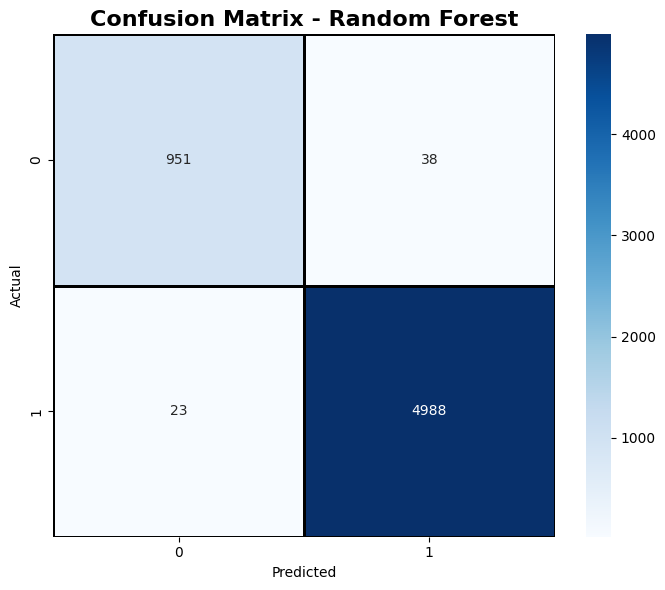

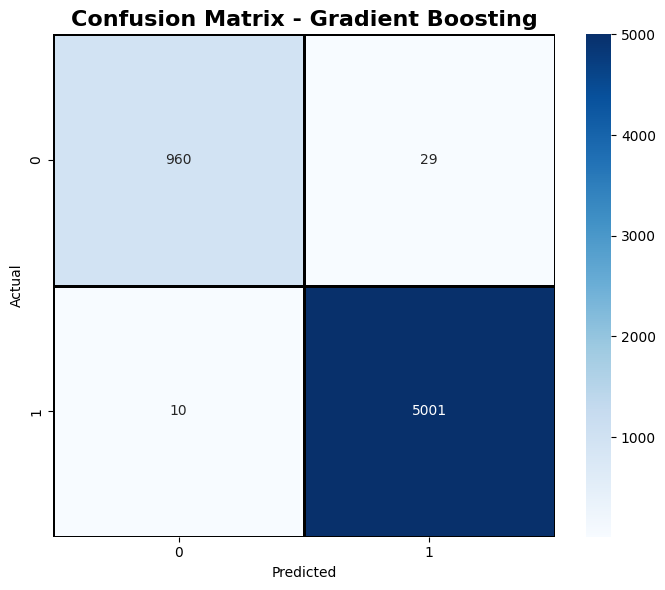

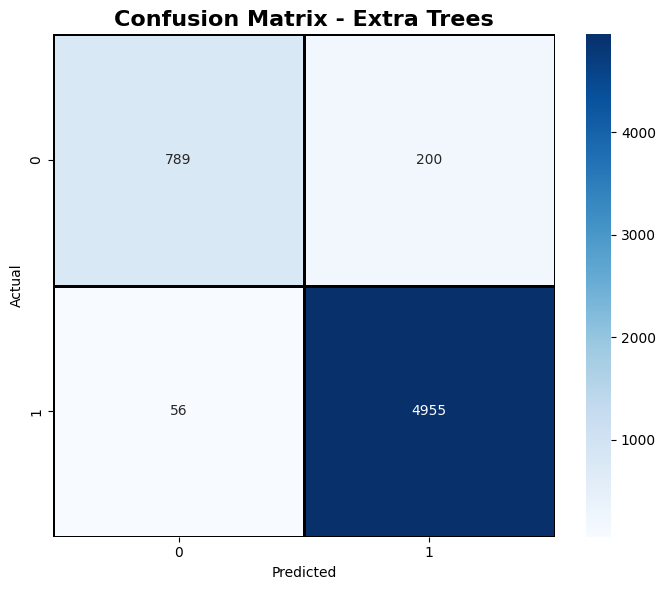

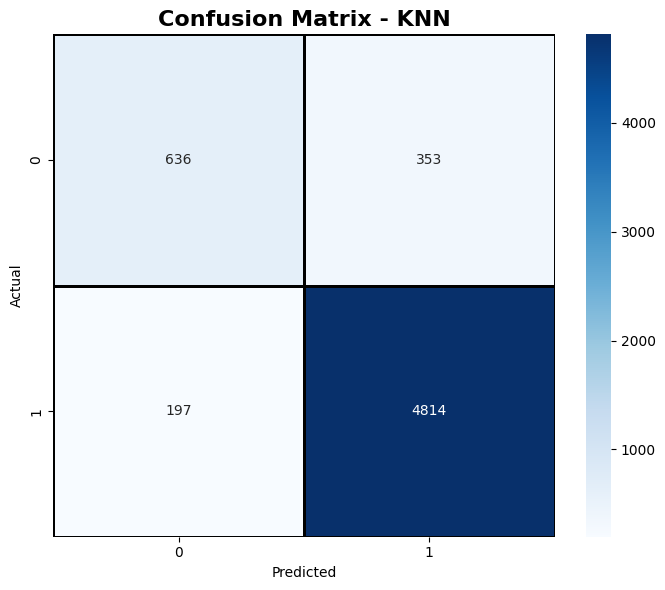

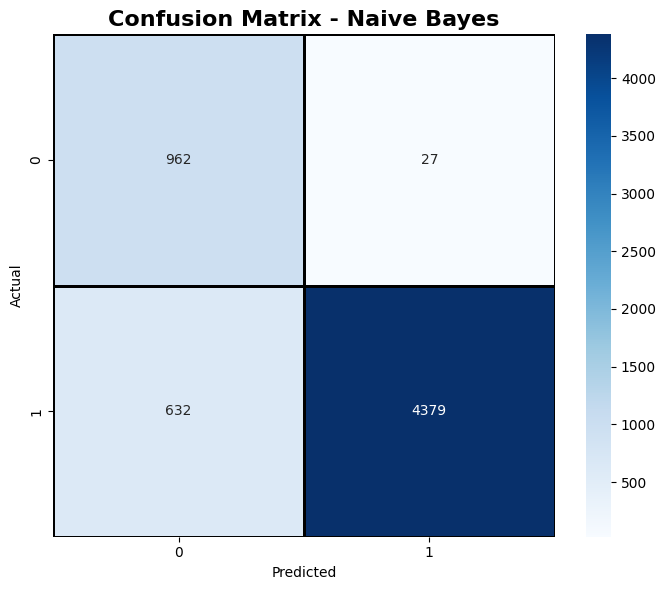


Random Forest Feature Importance:


,Feature,Importance
11,added_earnings_10yr_usd,0.436428
12,earnings_10yr_usd,0.205297
8,net_cost_usd,0.123427
0,major,0.061485
1,major_category,0.053315
10,hs_baseline_10yr_usd,0.027937
3,institution_selectivity_pctile,0.023506
9,debt_usd,0.018839
2,institution_tier,0.017525
6,completed_on_time,0.016360


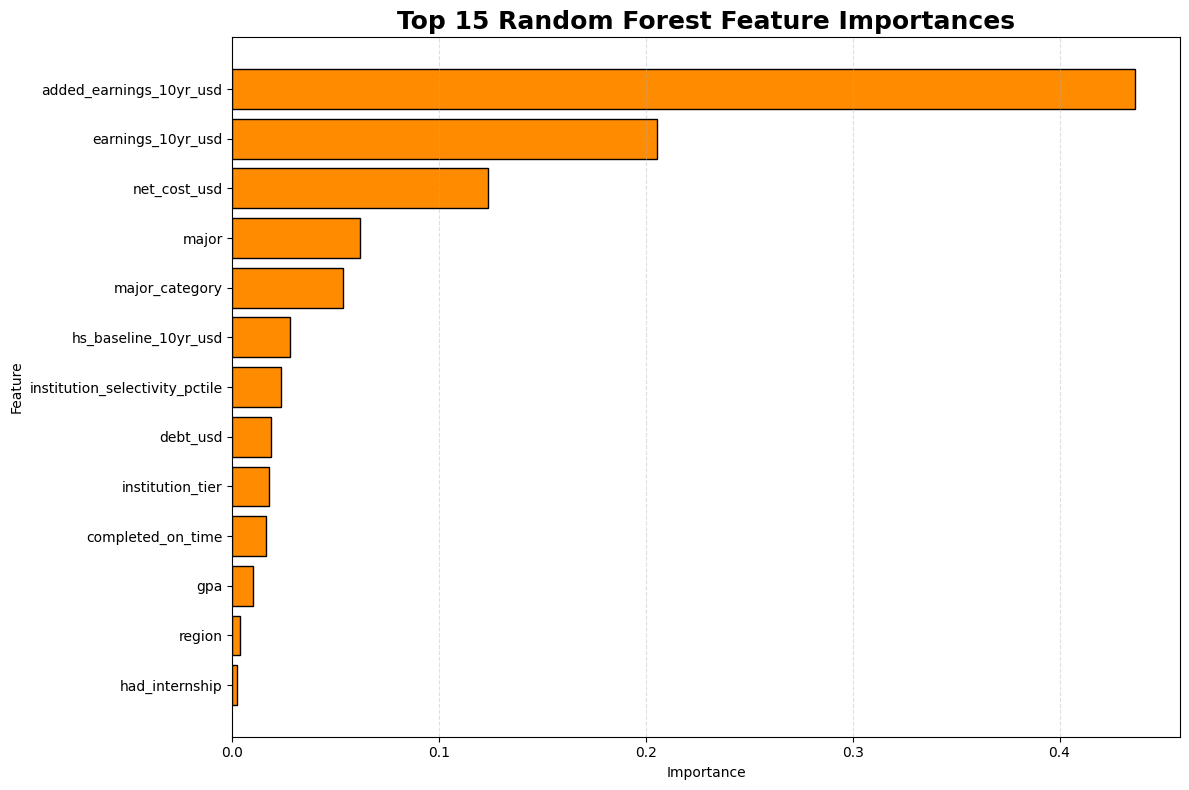


MODEL WITH HIGHEST ROC-AUC
Model: Logistic Regression
ROC-AUC: 1.0000

FINAL MODEL PERFORMANCE


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,99.68%,99.76%,99.86%,99.81%,1.000
1,Gradient Boosting,99.35%,99.42%,99.80%,99.61%,1.000
2,Random Forest,98.98%,99.24%,99.54%,99.39%,0.999
3,Extra Trees,95.73%,96.12%,98.88%,97.48%,0.993
4,Decision Tree,99.28%,99.52%,99.62%,99.57%,0.989
5,Naive Bayes,89.02%,99.39%,87.39%,93.00%,0.964
6,KNN,90.83%,93.17%,96.07%,94.60%,0.939


In [14]:
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# ================================================================
# 2. CHECK DATASET
# ================================================================

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

# ================================================================
# 3. DEFINE TARGET
# ================================================================

# Target variable
target = 'positive_roi'

print("\nTarget Variable:", target)

print("\nTarget Distribution:")
print(df[target].value_counts())

print("\nTarget Percentage:")
print(df[target].value_counts(normalize=True) * 100)


# ================================================================
# 4. REMOVE TARGET LEAKAGE
# ================================================================

# grad_id = identifier
#
# net_roi_usd and roi_pct directly describe ROI.
# high_roi is another ROI-derived target.
#
# Using these variables to predict positive_roi would cause
# target leakage.

drop_columns = [
    'grad_id',
    'net_roi_usd',
    'roi_pct',
    'high_roi'
]

# Keep only columns that actually exist
drop_columns = [col for col in drop_columns if col in df.columns]

model_df = df.drop(columns=drop_columns).copy()

print("\nColumns removed:")
print(drop_columns)

print("\nRemaining columns:")
print(model_df.columns.tolist())


# ================================================================
# 5. REMOVE ROWS WITH MISSING TARGET
# ================================================================

model_df = model_df.dropna(subset=[target]).copy()

print("\nShape after removing missing target:")
print(model_df.shape)


# ================================================================
# 6. SEPARATE X AND y
# ================================================================

X = model_df.drop(columns=[target])
y = model_df[target]

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)

print("\nTarget Values:")
print(y.unique())


# ================================================================
# 7. ENCODE TARGET VARIABLE
# ================================================================

# LabelEncoder converts:
# False / True
# or
# No / Yes
#
# into numerical classes.

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y.astype(str))

print("\nEncoded Target Classes:")
print(target_encoder.classes_)

print("\nEncoded Target Distribution:")
print(pd.Series(y).value_counts())


# ================================================================
# 8. IDENTIFY CATEGORICAL AND NUMERICAL COLUMNS
# ================================================================

categorical_columns = X.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

numerical_columns = X.select_dtypes(
    include=[np.number]
).columns.tolist()

print("\nCategorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)


# ================================================================
# 9. HANDLE MISSING VALUES
# ================================================================

# Numerical columns -> median
for col in numerical_columns:
    X[col] = X[col].fillna(X[col].median())

# Categorical columns -> mode
for col in categorical_columns:
    if X[col].mode().empty:
        X[col] = X[col].fillna("Unknown")
    else:
        X[col] = X[col].fillna(X[col].mode()[0])


# ================================================================
# 10. TRAIN-TEST SPLIT
# ================================================================

# IMPORTANT:
# Split BEFORE fitting encoders/scalers.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

print("\nTraining Target Distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting Target Distribution:")
print(pd.Series(y_test).value_counts())


# ================================================================
# 11. LABEL ENCODING FOR CATEGORICAL FEATURES
# ================================================================

# We use LabelEncoder separately for every categorical column.
#
# IMPORTANT:
# The encoder is fitted ONLY on training data.
# Then the same mapping is applied to test data.

label_encoders = {}

for col in categorical_columns:

    encoder = LabelEncoder()

    # Convert to string so mixed categories do not cause errors
    train_values = X_train[col].astype(str)
    test_values = X_test[col].astype(str)

    # Fit only on training values
    encoder.fit(train_values)

    # Transform training data
    X_train[col] = encoder.transform(train_values)

    # Handle unseen test categories safely
    mapping = {
        value: index
        for index, value in enumerate(encoder.classes_)
    }

    X_test[col] = test_values.map(mapping).fillna(-1).astype(int)

    label_encoders[col] = encoder

print("\nLabel Encoding Completed.")

for col, encoder in label_encoders.items():
    print(f"\n{col}:")
    print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))


# ================================================================
# 12. CONVERT ALL DATA TO NUMERIC
# ================================================================

X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

# Replace any remaining NaN/inf
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())


# ================================================================
# 13. FEATURE SCALING
# ================================================================

# Scaling is useful for:
# Logistic Regression
# KNN
# Naive Bayes

# Fit scaler ONLY on training data.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nScaling Completed.")

print("Scaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape:", X_test_scaled.shape)


# ================================================================
# 14. DEFINE ML MODELS
# ================================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=7
    ),

    "Naive Bayes": GaussianNB()
}


# ================================================================
# 15. TRAIN MODELS
# ================================================================

results = []

trained_models = {}

roc_data = {}

for name, model in models.items():

    print("\n" + "=" * 70)
    print("Training:", name)
    print("=" * 70)

    # Use scaled data for Logistic Regression, KNN and Naive Bayes
    if name in [
        "Logistic Regression",
        "KNN",
        "Naive Bayes"
    ]:
        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)

        if hasattr(model, "predict_proba"):
            y_probability = model.predict_proba(X_test_scaled)[:, 1]
        else:
            y_probability = model.decision_function(X_test_scaled)

    else:
        # Tree-based models do not require scaling
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        if hasattr(model, "predict_proba"):
            y_probability = model.predict_proba(X_test)[:, 1]
        else:
            y_probability = model.decision_function(X_test)

    # Save trained model
    trained_models[name] = model

    # ------------------------------------------------------------
    # Metrics
    # ------------------------------------------------------------

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_probability
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    # ------------------------------------------------------------
    # ROC Data
    # ------------------------------------------------------------

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_probability
    )

    roc_data[name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc_auc
    }

    # ------------------------------------------------------------
    # Classification Report
    # ------------------------------------------------------------

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=target_encoder.classes_.astype(str),
            zero_division=0
        )
    )


# ================================================================
# 16. MODEL COMPARISON TABLE
# ================================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)


# ================================================================
# 17. ACCURACY COMPARISON
# ================================================================

plt.figure(figsize=(12, 7))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"],
    color=[
        "royalblue",
        "orange",
        "seagreen",
        "crimson",
        "purple",
        "teal",
        "gold"
    ][:len(results_df)],
    edgecolor="black"
)

plt.title(
    "ML Model Accuracy Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1.05)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# Add values on bars
for i, value in enumerate(results_df["Accuracy"]):

    plt.text(
        i,
        value + 0.02,
        f"{value:.2%}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


# ================================================================
# 18. F1 SCORE COMPARISON
# ================================================================

plt.figure(figsize=(12, 7))

plt.bar(
    results_df["Model"],
    results_df["F1 Score"],
    color="mediumorchid",
    edgecolor="black"
)

plt.title(
    "F1 Score Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("F1 Score")

plt.ylim(0, 1.05)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for i, value in enumerate(results_df["F1 Score"]):

    plt.text(
        i,
        value + 0.02,
        f"{value:.2%}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


# ================================================================
# 19. ROC-AUC COMPARISON
# ================================================================

plt.figure(figsize=(12, 7))

plt.bar(
    results_df["Model"],
    results_df["ROC-AUC"],
    color="darkcyan",
    edgecolor="black"
)

plt.title(
    "ROC-AUC Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("ROC-AUC")

plt.ylim(0, 1.05)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for i, value in enumerate(results_df["ROC-AUC"]):

    plt.text(
        i,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


# ================================================================
# 20. ROC CURVE FOR ALL MODELS
# ================================================================

plt.figure(figsize=(12, 9))

roc_colors = [
    "blue",
    "red",
    "green",
    "purple",
    "orange",
    "brown",
    "teal"
]

for (name, data), color in zip(
    roc_data.items(),
    roc_colors
):

    plt.plot(
        data["fpr"],
        data["tpr"],
        color=color,
        linewidth=2.5,
        label=f"{name} (AUC = {data['auc']:.3f})"
    )

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    color="black",
    linestyle="--",
    linewidth=2,
    label="Random Classifier (AUC = 0.500)"
)

plt.title(
    "ROC Curves - All Machine Learning Models",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=13
)

plt.ylabel(
    "True Positive Rate",
    fontsize=13
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.grid(
    linestyle="--",
    alpha=0.35
)

plt.legend(
    loc="lower right",
    fontsize=10
)

plt.tight_layout()
plt.show()


# ================================================================
# 21. CONFUSION MATRICES FOR ALL MODELS
# ================================================================

for name, model in trained_models.items():

    if name in [
        "Logistic Regression",
        "KNN",
        "Naive Bayes"
    ]:
        predictions = model.predict(X_test_scaled)
    else:
        predictions = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        predictions
    )

    plt.figure(figsize=(7, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        linewidths=1,
        linecolor="black",
        xticklabels=target_encoder.classes_,
        yticklabels=target_encoder.classes_
    )

    plt.title(
        f"Confusion Matrix - {name}",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()


# ================================================================
# 22. FEATURE IMPORTANCE - RANDOM FOREST
# ================================================================

rf_model = trained_models["Random Forest"]

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nRandom Forest Feature Importance:")
display(feature_importance)


# ================================================================
# 23. RANDOM FOREST FEATURE IMPORTANCE PLOT
# ================================================================

top_features = feature_importance.head(15)

plt.figure(figsize=(12, 8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1],
    color="darkorange",
    edgecolor="black"
)

plt.title(
    "Top 15 Random Forest Feature Importances",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()


# ================================================================
# 24. FINAL BEST MODEL BY ROC-AUC
# ================================================================

best_model_name = results_df.iloc[0]["Model"]
best_auc = results_df.iloc[0]["ROC-AUC"]

print("\n" + "=" * 70)
print("MODEL WITH HIGHEST ROC-AUC")
print("=" * 70)

print("Model:", best_model_name)
print(f"ROC-AUC: {best_auc:.4f}")


# ================================================================
# 25. FINAL SUMMARY
# ================================================================

print("\n" + "=" * 80)
print("FINAL MODEL PERFORMANCE")
print("=" * 80)

display(
    results_df[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC"
        ]
    ].style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1 Score": "{:.2%}",
        "ROC-AUC": "{:.3f}"
    })
)

## Thank you..pls upvote!!!!!!!!!!